In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
sns.set_theme(style="whitegrid")

In [44]:
data = np.load("/lustre/home/barmstrong/ssm_bench/outputs/2026-01-25/11-46-43/2be0/test_outputs/test_outputs.npz")
print(list(data.keys()))

['inputs', 'chi1', 'chi2', 'chirp_mass', 'dec', 'distance', 'inclination', 'labels', 'mass_1', 'mass_2', 'mass_ratio', 'phi', 'phic', 'psi', 's1x', 's1y', 's1z', 's2x', 's2y', 's2z', 'snr', 'offset', 'index', 'label', 'dec_psi_phi', 'mass_params', 'output_label', 'output_mass_params', 'output_snr']


/tmp/ipykernel_3657566/3884222284.py:8: RuntimeWarning: divide by zero encountered in divide
  rel_chirp_mass_uncertainty = chirp_mass_uncertainty / chirp_mass_pred


Text(0.5, 1.0, 'Chirp Mass Prediction')

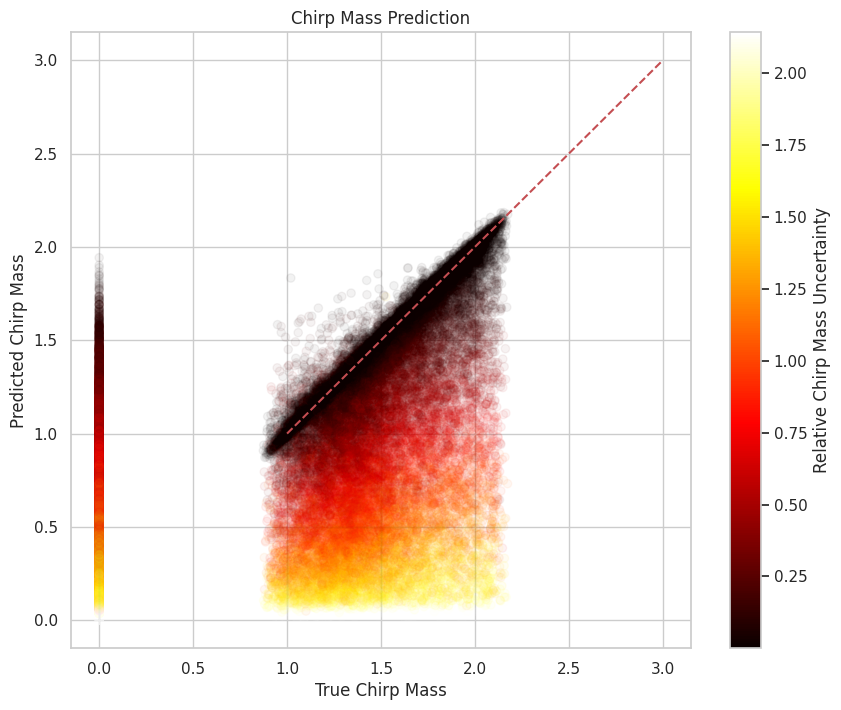

In [45]:
chirp_mass_pred = data["output_mass_params"][:, 0]
mass_ratio_pred = data["output_mass_params"][:, 1]

chirp_mass_true = data["mass_params"][:, 0]
mass_ratio_true = data["mass_params"][:, 1]

chirp_mass_uncertainty = data["output_mass_params"][:, 2]
rel_chirp_mass_uncertainty = chirp_mass_uncertainty / chirp_mass_pred

fig, ax = plt.subplots(figsize=(10, 8))

# Set colorbar bounds based on percentiles to avoid outliers
vmin, vmax = np.percentile(rel_chirp_mass_uncertainty, [5, 95])

scatter = ax.scatter(chirp_mass_true, chirp_mass_pred, alpha=0.05, 
                      c=rel_chirp_mass_uncertainty, cmap='hot', vmin=vmin, vmax=vmax)

# Create colorbar with full opacity using a separate ScalarMappable
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
sm = ScalarMappable(cmap='hot', norm=Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Relative Chirp Mass Uncertainty')

ax.plot([1, 3], [1, 3], 'r--')
ax.set_xlabel("True Chirp Mass")
ax.set_ylabel("Predicted Chirp Mass")
ax.set_title("Chirp Mass Prediction")

In [46]:
log_ticks = list(range(8, 20, 2)) + list(range(20, 101, 10))

/tmp/ipykernel_3657566/2572563024.py:2: RuntimeWarning: divide by zero encountered in divide
  rel_chirp_mass_error = ((chirp_mass_pred - chirp_mass_true) / chirp_mass_true).flatten()
/tmp/ipykernel_3657566/2572563024.py:2: RuntimeWarning: invalid value encountered in divide
  rel_chirp_mass_error = ((chirp_mass_pred - chirp_mass_true) / chirp_mass_true).flatten()
/tmp/ipykernel_3657566/2572563024.py:4: RuntimeWarning: divide by zero encountered in divide
  rel_chirp_mass_uncertainty = (chirp_mass_uncertainty / chirp_mass_pred).flatten()


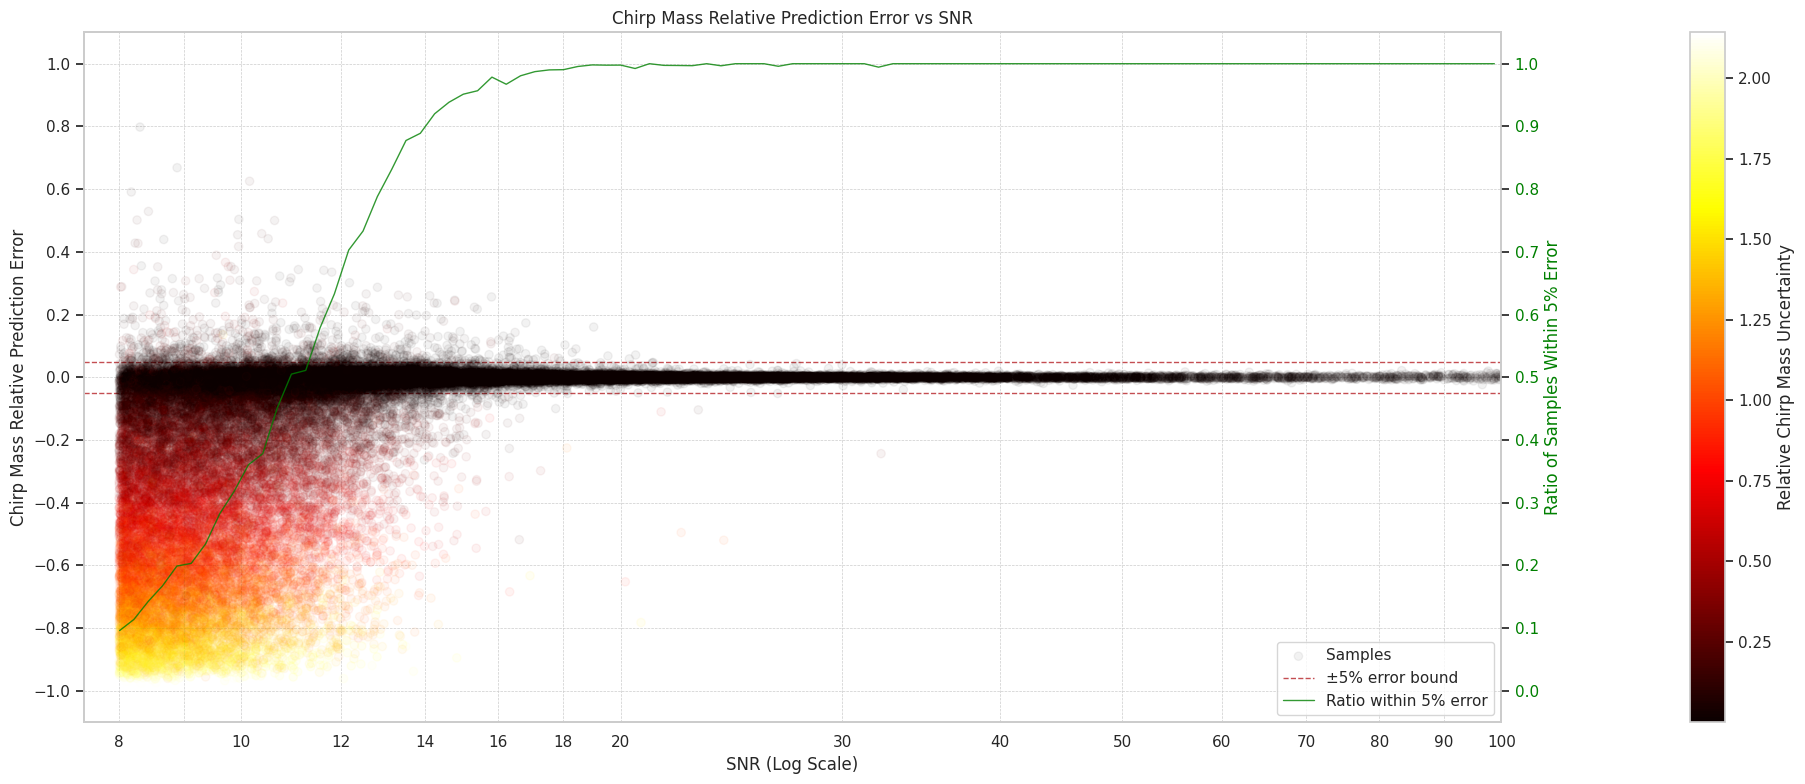

In [47]:
snr = data["snr"].flatten()
rel_chirp_mass_error = ((chirp_mass_pred - chirp_mass_true) / chirp_mass_true).flatten()
chirp_mass_uncertainty = data["output_mass_params"][:, 2].flatten()
rel_chirp_mass_uncertainty = (chirp_mass_uncertainty / chirp_mass_pred).flatten()

# Calculate ratio of samples within 5% error for SNR bins
snr_bins = np.logspace(np.log10(7.5), np.log10(100), 100)
bin_centers = (snr_bins[:-1] + snr_bins[1:]) / 2
bin_indices = np.digitize(snr, snr_bins)

within_5pct_ratio = []
for i in range(1, len(snr_bins)):
    mask = bin_indices == i
    if np.sum(mask) > 0:
        ratio = np.mean(np.abs(rel_chirp_mass_error[mask]) <= 0.05)
        within_5pct_ratio.append(ratio)
    else:
        within_5pct_ratio.append(np.nan)

fig, ax1 = plt.subplots(figsize=(20, 8))

# Set colorbar bounds based on percentiles to avoid outliers
vmin, vmax = np.percentile(rel_chirp_mass_uncertainty, [5, 95])

# Scatter plot on primary axis with heat coloring by relative uncertainty
scatter = ax1.scatter(snr, rel_chirp_mass_error, alpha=0.05, zorder=5, label='Samples',
                      c=rel_chirp_mass_uncertainty, cmap='hot', vmin=vmin, vmax=vmax)

# Create colorbar with full opacity using a separate ScalarMappable
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
sm = ScalarMappable(cmap='hot', norm=Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax1, pad=0.1)
cbar.set_label('Relative Chirp Mass Uncertainty')

ax1.set_xscale("log")
ax1.set_xticks(log_ticks)
ax1.set_xticklabels([str(tick) for tick in log_ticks])
ax1.set_ylim(-1.1, 1.1)

# mark 5% error lines
ax1.axhline(0.05, color='r', linestyle='--', zorder=0, linewidth=1, label='±5% error bound')
ax1.axhline(-0.05, color='r', linestyle='--', zorder=0, linewidth=1)
ax1.set_xlim(7.5, 100)
ax1.set_ylabel("Chirp Mass Relative Prediction Error")
ax1.set_xlabel("SNR (Log Scale)")
ax1.set_yticks(np.linspace(-1, 1,11))
ax1.grid(True, which='both', linestyle='--', linewidth=0.5, zorder=0)

# Secondary axis for ratio within 5% error
ax2 = ax1.twinx()
ax2.plot(bin_centers, within_5pct_ratio, color='green', linewidth=1, alpha=0.8, label='Ratio within 5% error', zorder=1)
ax2.set_ylabel("Ratio of Samples Within 5% Error", color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.set_yticks(np.linspace(0, 1,11))
ax2.set_ylim(-0.05, 1.05)
ax2.grid(False)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

plt.title("Chirp Mass Relative Prediction Error vs SNR")
plt.savefig("chirp_mass_error_vs_snr.png", dpi=300)
plt.tight_layout()